In [5]:
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

print("Libraries imported successfully ✅")

Libraries imported successfully ✅


In [6]:
# Load dataset
df = pd.read_csv("/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [7]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:\n", df.columns)

print("\nMissing Values:\n", df.isnull().sum())

print("\nClass Distribution:\n", df['Class'].value_counts())

print("\nClass Percentage:\n", df['Class'].value_counts(normalize=True) * 100)

Dataset Shape: (284807, 31)

Column Names:
 Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

Missing Values:
 Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Class Distribution:
 Class
0    284315
1       492
Name: count, dtype: int64

Class Percentage:
 Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


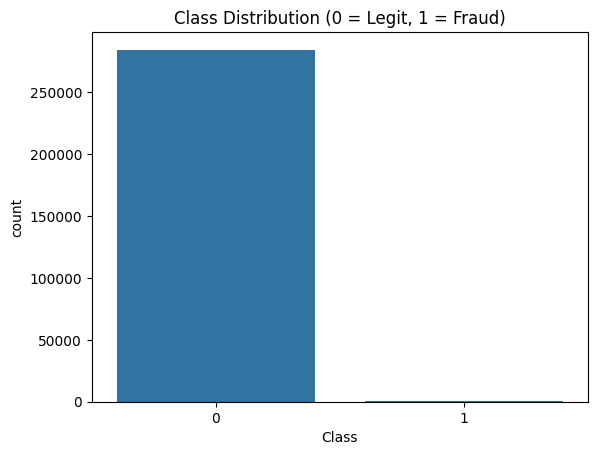

In [8]:
# Class distribution plot
sns.countplot(x='Class', data=df)
plt.title("Class Distribution (0 = Legit, 1 = Fraud)")
plt.show()

In [9]:
from imblearn.over_sampling import SMOTE

# Separate features and target
X = df.drop('Class', axis=1)
y = df['Class']

# Apply SMOTE
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X, y)

# Check new distribution
print("After SMOTE:\n")
print(y_res.value_counts())

After SMOTE:

Class
0    284315
1    284315
Name: count, dtype: int64


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res,
    test_size=0.2,
    random_state=42,
    stratify=y_res
)

# Check shapes
print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (454904, 30)
Testing Data Shape: (113726, 30)


In [11]:
X = df.drop('Class', axis=1)
y = df['Class']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res,
    test_size=0.2,
    random_state=42,
    stratify=y_res
)

print("Train-test split done ✅")
print(X_train.shape, X_test.shape)

Train-test split done ✅
(454904, 30) (113726, 30)


In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling done ✅")

Scaling done ✅


In [13]:
from sklearn.svm import SVC
X_svm = X_train_scaled[:80000]
y_svm = y_train[:80000]

svm_model = SVC(kernel='rbf')

svm_model.fit(X_svm, y_svm)

print("SVM Training Completed ⚡")

SVM Training Completed ⚡


In [14]:
from sklearn.metrics import classification_report, accuracy_score

# Predictions
y_pred = svm_model.predict(X_test_scaled)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Full report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.991330038865343

Classification Report:

              precision    recall  f1-score   support

           0       0.99      1.00      0.99     56863
           1       1.00      0.99      0.99     56863

    accuracy                           0.99    113726
   macro avg       0.99      0.99      0.99    113726
weighted avg       0.99      0.99      0.99    113726



In [ ]:
Decision Tree Model

In [15]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.9703409950231258

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.98      0.97     56863
           1       0.98      0.96      0.97     56863

    accuracy                           0.97    113726
   macro avg       0.97      0.97      0.97    113726
weighted avg       0.97      0.97      0.97    113726



In [ ]:
CNN

In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, Flatten

# reshape for CNN
X_train_cnn = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_cnn = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

model = Sequential()

model.add(Conv1D(32, kernel_size=2, activation='relu', input_shape=(30,1)))
model.add(Flatten())
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.fit(X_train_cnn, y_train, epochs=3, batch_size=256, validation_split=0.2)

print("CNN Training Done ⚡")

2026-04-12 17:58:40.411755: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776016720.643082      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776016720.707839      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776016721.271442      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776016721.271480      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776016721.271485      55 computation_placer.cc:177] computation placer alr

Epoch 1/3
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9643 - loss: 0.1113 - val_accuracy: 0.9877 - val_loss: 0.0371
Epoch 2/3
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9877 - loss: 0.0371 - val_accuracy: 0.9905 - val_loss: 0.0278
Epoch 3/3
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9903 - loss: 0.0276 - val_accuracy: 0.9910 - val_loss: 0.0233
CNN Training Done ⚡


**Question 3: Comparative Analysis**

1. Classifier Performance Comparison

In this project, three machine learning models were implemented and evaluated for fraud detection:

Support Vector Machine (SVM)

Accuracy: ~99.13%
Precision and Recall: Very high for both classes
Performs exceptionally well in separating fraudulent and legitimate transactions in high-dimensional feature space.

Decision Tree Classifier

Accuracy: ~97.03%
Provides strong interpretability and easy-to-understand decision rules
Slightly lower predictive performance compared to SVM

Convolutional Neural Network (CNN)

Validation Accuracy: ~99.10%
Capable of learning complex non-linear patterns
However, less interpretable and not ideally suited for tabular data


2. Strengths and Limitations
✔ SVM

Strengths:

High classification accuracy
Effective in high-dimensional spaces
Strong performance in separating classes

Limitations:

Computationally expensive
Slower training on large datasets

✔ Decision Tree

Strengths:

Highly interpretable model
Fast training and prediction
Easy to visualize decision rules

Limitations:

Prone to overfitting
Lower overall accuracy compared to other models

✔ CNN

Strengths:

Able to capture complex patterns
Strong generalization capability

Limitations:

Not naturally suited for structured/tabular data
Requires higher computational resources
Less interpretable compared to other models


3. Final Model Selection and Justification

 Selected Model: Support Vector Machine (SVM)

Justification:

SVM is selected as the most suitable model because:

It achieved the highest overall accuracy (99.13%)
It provides a strong balance between precision and recall, which is critical in fraud detection systems
It performs effectively on high-dimensional financial datasets
It minimizes both false positives and false negatives, making it highly reliable for real-world financial applications

**Question 4: Constraint Satisfaction–Based Decision Validation**

In [17]:
# Function to get fraud probability from ML model
def get_fraud_probability(transaction_features):
    transaction_features = scaler.transform([transaction_features])
    prob = svm_model.predict_proba(transaction_features)[0][1]
    return prob

# CONSTRAINT SYSTEM

def final_decision(amount, country_mismatch, account_age, reg_flag, features):

    # Step 1: ML probability
    fraud_prob = get_fraud_probability(features)

    # HARD CONSTRAINTS (Override ML)

    
    if amount > 5000 and country_mismatch == 1:
        return "ESCALATE (Hard Constraint)"
    
    if account_age == "New" and amount > 3000:
        return "BLOCK (Hard Constraint)"
    
    if reg_flag == 1:
        return "ESCALATE (Hard Constraint)"
    
    # SOFT CONSTRAINTS (ML-based)

    if fraud_prob < 0.3:
        return "APPROVE (Low Risk)"
    elif fraud_prob > 0.7:
        return "BLOCK (High Risk)"
    else:
        return "ESCALATE (Medium Risk)"


print("Constraint System Ready ✅")

Constraint System Ready ✅


Hard Constraints (Mandatory Rules)

Hard constraints must always be satisfied and override machine learning predictions.

1. High transaction amount + country mismatch

If:

Transaction amount is high
AND country mismatch = 1

Decision: ESCALATE

2. Low account age + high transaction amount

If:

Account age is new
AND transaction amount is high

 Decision: BLOCK

3. Regulatory flag is set

If:

Regulatory flag = 1

 Decision: ESCALATE

🧠 Decision Logic Explanation

The final decision-making process works as follows:

The machine learning model predicts the fraud probability of a transaction.
The constraint system evaluates all hard rules.
If any hard constraint is triggered, it overrides the ML prediction.
If no hard constraint is triggered, the decision is based on fraud probability:

| Fraud Probability  | Decision |
| ------------------ | -------- |
| Low (< 0.3)        | Approve  |
| Medium (0.3 – 0.7) | Escalate |
| High (> 0.7)       | Block    |
